<a href="https://colab.research.google.com/github/Kuoz2/An-lisis_y_Predicci-n/blob/main/titanic_competicion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis Predictivo de Supervivencia en el Titanic

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## Importación de Librerías

En esta sección, importamos las librerías necesarias para el análisis de datos, visualización, preprocesamiento y construcción de modelos de Machine Learning. Se incluyen `pandas` para manipulación de datos, `numpy` para operaciones numéricas, `matplotlib` y `seaborn` para visualización, y `warnings` para controlar mensajes de advertencia.

In [2]:
dk= pd.read_csv("/content/drive/MyDrive/CURSOPYTHON/train.csv")

## Carga de Datos

Cargamos el conjunto de datos `train.csv` en un DataFrame de pandas llamado `dk`. Este dataset contiene información sobre los pasajeros del Titanic, incluyendo si sobrevivieron o no.

In [4]:
print("--- Estructura del Dataset ---")
display(dk.info())
print("\n--- Estadísticas Descriptivas ---")
display(dk.describe())

--- Estructura del Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


None


--- Estadísticas Descriptivas ---


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## Exploración Inicial de Datos

Realizamos una exploración inicial del dataset para entender su estructura, tipos de datos, y estadísticas descriptivas. Esto nos ayuda a identificar posibles problemas como valores nulos o tipos de datos incorrectos.

In [5]:
print("Valores nulos")
print(dk.isna().sum())

Valores nulos
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


## Verificación de Valores Nulos

Identificamos la cantidad de valores nulos en cada columna del dataset. Esto es crucial para la fase de preprocesamiento, donde tendremos que decidir cómo manejar estos valores faltantes.

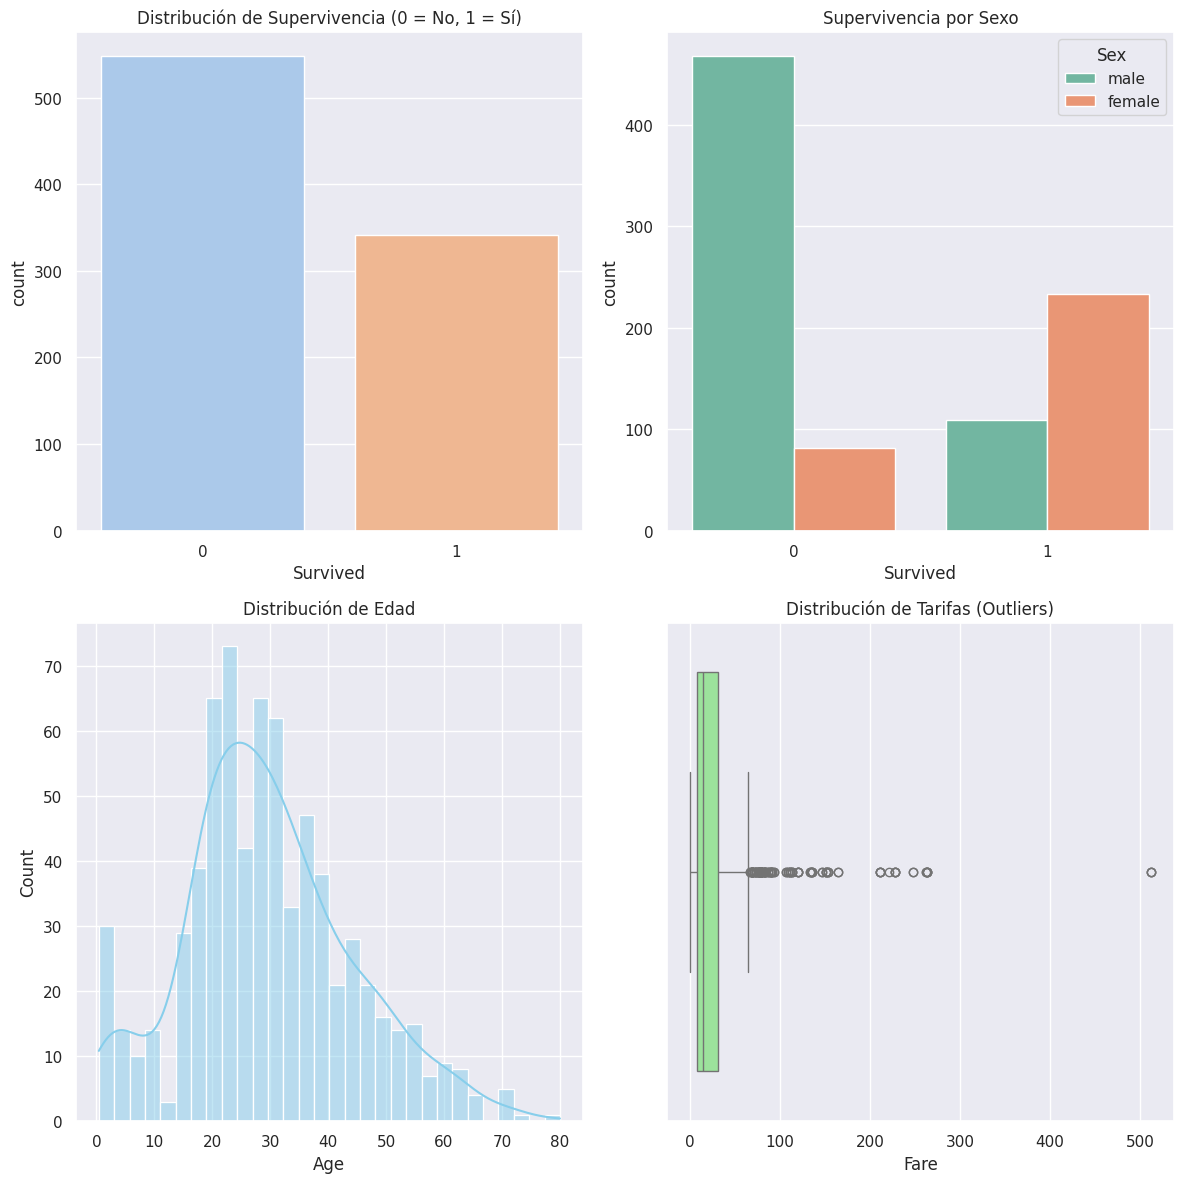

In [15]:
sns.set_theme(style="darkgrid")
fig, axes= plt.subplots(2,2,figsize=(12,12))
sns.countplot(x='Survived',data=dk,palette='pastel', ax=axes[0,0])
axes[0, 0].set_title('Distribución de Supervivencia (0 = No, 1 = Sí)')
sns.countplot(x='Survived',hue='Sex',data=dk,palette='Set2', ax=axes[0,1])
axes[0, 1].set_title('Supervivencia por Sexo')
sns.histplot(dk['Age'].dropna(), bins=30, kde=True, color='skyblue', ax=axes[1,0])
axes[1, 0].set_title('Distribución de Edad')
sns.boxplot(x=dk['Fare'], color='lightgreen', ax=axes[1, 1])
axes[1, 1].set_title('Distribución de Tarifas (Outliers)')
plt.tight_layout()
plt.show()

## Análisis Exploratorio de Datos (EDA) - Visualización

Visualizamos las distribuciones de algunas de las variables clave y sus relaciones con la supervivencia. Los gráficos incluyen:
- Distribución general de supervivencia.
- Supervivencia por sexo.
- Distribución de edad.
- Distribución de tarifas, mostrando posibles outliers.

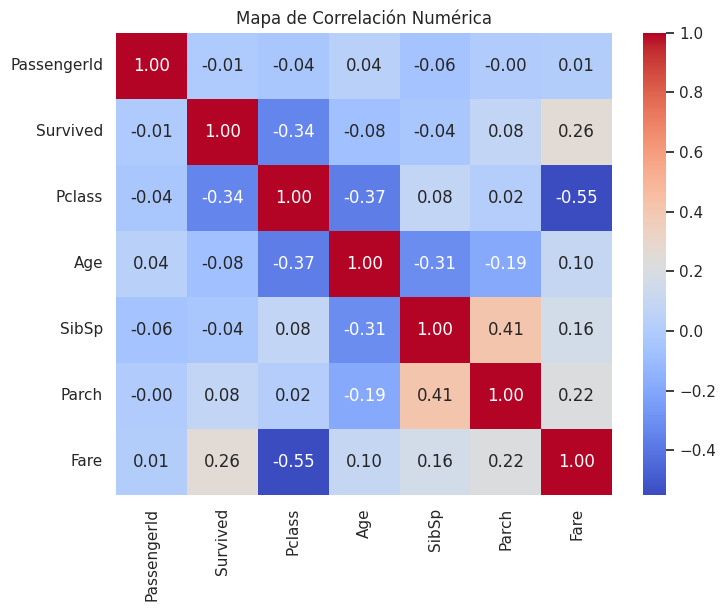

In [16]:
plt.figure(figsize=(8,6))
sns.heatmap(dk.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Mapa de Correlación Numérica')
plt.show()
#

## Mapa de Correlación

Calculamos y visualizamos la matriz de correlación entre las variables numéricas. Esto nos ayuda a entender la relación lineal entre las características y con la variable objetivo `Survived`.

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

## Importación de Módulos para Preprocesamiento y Modelado

Importamos las clases necesarias de `sklearn` para la creación del pipeline de preprocesamiento, incluyendo división de datos, imputación de valores faltantes, escalado de características y codificación One-Hot para variables categóricas.

In [19]:
x= dk.drop(columns=['PassengerId', 'Survived', 'Name', 'Ticket', 'Cabin'])
y= dk['Survived']

nums_col= x.select_dtypes(include=['int64', 'float64']).columns
cats_col= x.select_dtypes(include=['object']).columns


num_tranform= Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_tranfor= Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

preprocessor= ColumnTransformer(transformers=[
    ('num', num_tranform, nums_col),
    ('cat', cat_tranfor, cats_col)
])

x_train, x_test, y_train, y_test= train_test_split(x, y, test_size=0.2, random_state=42)

x_train_proc= preprocessor.fit_transform(x_train)
x_test_proc= preprocessor.transform(x_test)

## Preprocesamiento de Datos y División en Conjuntos de Entrenamiento y Prueba

En esta sección, preparamos los datos para el modelado:
- Separamos las características (`x`) de la variable objetivo (`y`, 'Survived').
- Identificamos columnas numéricas y categóricas.
- Creamos pipelines para el preprocesamiento de columnas numéricas (imputación por mediana y escalado) y categóricas (imputación por moda y codificación One-Hot).
- Combinamos estos pipelines en un `ColumnTransformer`.
- Dividimos el dataset en conjuntos de entrenamiento y prueba (`x_train`, `x_test`, `y_train`, `y_test`).
- Aplicamos el preprocesamiento a los conjuntos de entrenamiento y prueba.

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import cross_val_score, RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report

## Importación de Modelos de Machine Learning y Métricas

Importamos varios algoritmos de clasificación de `sklearn` y `xgboost`/`lightgbm`, así como módulos para validación cruzada (`cross_val_score`), búsqueda aleatoria de hiperparámetros (`RandomizedSearchCV`), y métricas de evaluación del modelo (`accuracy_score`, `classification_report`).

In [21]:
modelos= {
    'Regresión Logística': LogisticRegression(),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Árboles de Decisión': DecisionTreeClassifier(),
    'XGBoost': XGBClassifier(),
    'LightGBM': LGBMClassifier()
}

resultadis=[]
print("--- Benchmark de Modelos (Cross-Validation CV=5) ---")
for nombre, modelo in modelos.items():
    scores = cross_val_score(modelo, x_train_proc, y_train, cv=5, scoring='accuracy', n_jobs=-1)
    resultadis.append({'Modelo': nombre, 'Accuracy Medio': scores.mean(), 'Desviación': scores.std()})
dk_benchmark= pd.DataFrame(resultadis).sort_values(by='Accuracy Medio', ascending=False)
display(dk_benchmark)
print("\n=== Optimizador de hiper parametros === ")

params_dist= {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0]
}

--- Benchmark de Modelos (Cross-Validation CV=5) ---


,Modelo,Accuracy Medio,Desviación
4,LightGBM,0.814607,0.011352
3,XGBoost,0.790752,0.014010
1,K-Nearest Neighbors,0.790732,0.017438
0,Regresión Logística,0.790663,0.027686
2,Árboles de Decisión,0.745829,0.022285



=== Optimizador de hiper parametros === 


## Benchmark de Modelos y Configuración de Optimización de Hiperparámetros

Comparamos el rendimiento de diferentes modelos de clasificación utilizando validación cruzada. Se define un diccionario de modelos y se calculan sus puntuaciones de precisión media y desviación estándar.

Posteriormente, se configura el espacio de búsqueda de hiperparámetros (`params_dist`) para optimizar el modelo `XGBoost` utilizando `RandomizedSearchCV`.

In [23]:
random_search= RandomizedSearchCV(
   estimator=XGBClassifier(random_state=42, eval_metric='logloss'),
    param_distributions=params_dist,
    n_iter=10, cv=5, scoring='accuracy', random_state=42, n_jobs=-1
   )
random_search.fit(x_train_proc, y_train)
mejor_modelo= random_search.best_estimator_
print(f"Mejores parametros: {random_search.best_params_}")
y_pred_final= mejor_modelo.predict(x_test_proc)
print("\n--- Reporte de Clasificación del Modelo Optimizado ---")
print(f"Accuracy Final (Test): {accuracy_score(y_test, y_pred_final):.4f}")
print(classification_report(y_test, y_pred_final))

Mejores parametros: {'subsample': 0.8, 'n_estimators': 50, 'max_depth': 3, 'learning_rate': 0.05}

--- Reporte de Clasificación del Modelo Optimizado ---
Accuracy Final (Test): 0.8045
              precision    recall  f1-score   support

           0       0.80      0.90      0.84       105
           1       0.82      0.68      0.74        74

    accuracy                           0.80       179
   macro avg       0.81      0.79      0.79       179
weighted avg       0.81      0.80      0.80       179



## Optimización y Evaluación Final del Modelo

Ejecutamos la búsqueda aleatoria de hiperparámetros (`RandomizedSearchCV`) para encontrar la mejor configuración para el modelo `XGBoost`. Una vez encontrado el mejor modelo, realizamos predicciones sobre el conjunto de prueba (`x_test_proc`) y evaluamos su rendimiento final utilizando la precisión y un reporte de clasificación detallado.